
# Introduction to Matplotlib

Matplotlib is the most widely used Python library for creating static, animated, and interactive visualizations.  
It integrates well with **NumPy** and **Pandas**, making it ideal for data analysis and presentation.

In this notebook, we'll use a *Used Car Dataset* to explore common plot types and customization techniques.



## 1. Setup
Import libraries and load the dataset. We'll reuse the `used_cars_train.json` file from previous exercises.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import json

# Load dataset (assuming used_cars_train.json is available in the same directory)
records = []
with open("used_cars_train.json") as f:
    for line in f:
        records.append(json.loads(line))

df = pd.DataFrame(records)
df.head()


,id,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,drive,size,type,paint_color,state,posting_date
0,7314977535,4000,2007.0,jeep,grand cherokee limited,good,8 cylinders,gas,278000.0,clean,automatic,4wd,mid-size,SUV,silver,or,2021-04-30T12:43:00-0700
1,7314789720,4800,2006.0,chevrolet,silverado,good,8 cylinders,gas,260600.0,clean,automatic,rwd,full-size,pickup,white,fl,2021-04-30T10:31:34-0400
2,7304863686,5500,2007.0,toyota,yaris,excellent,4 cylinders,gas,51000.0,clean,manual,fwd,compact,hatchback,blue,al,2021-04-10T15:11:21-0500
3,7311469964,26990,2016.0,chevrolet,express commercial cutaway,good,8 cylinders,gas,75734.0,clean,automatic,rwd,full-size,truck,white,wi,2021-04-23T13:13:09-0500
4,7305988194,48995,2020.0,toyota,tundra limited 4x4,like new,8 cylinders,gas,20000.0,lien,automatic,4wd,full-size,truck,silver,nm,2021-04-12T20:01:35-0600



## 2. Basic Plotting

Let's start with a simple line plot and gradually move to more informative plots.


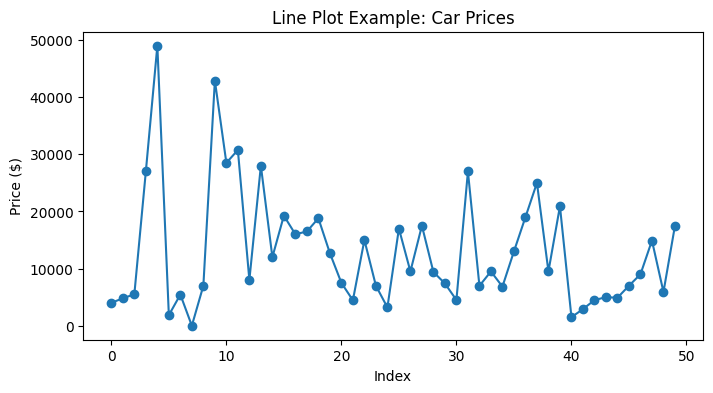

In [ ]:

# Example: Line plot
sample_data = df['price'].head(50).reset_index(drop=True)
plt.figure(figsize=(8,4))
plt.plot(sample_data, marker='o')
plt.title('Line Plot Example: Car Prices')
plt.xlabel('Index')
plt.ylabel('Price ($)')
#plt.xlim(xmin=0,xmax=20)
#plt.grid(True)
#plt.savefig("line_plot.png")
plt.show()


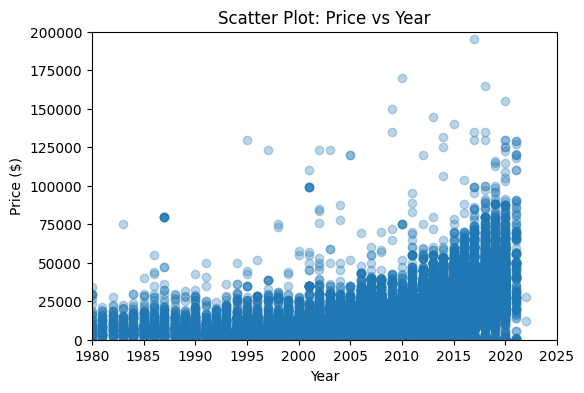

In [ ]:

# Example: Scatter plot
plt.figure(figsize=(6,4))
plt.scatter(df['year'], df['price'],alpha=0.3)
plt.title('Scatter Plot: Price vs Year')
plt.xlabel('Year')
plt.ylabel('Price ($)')
plt.xlim(1980, 2025)
plt.ylim(0, 200000)
plt.show()



### Bar Plot Example

Let's visualize the most common car manufacturers in the dataset.


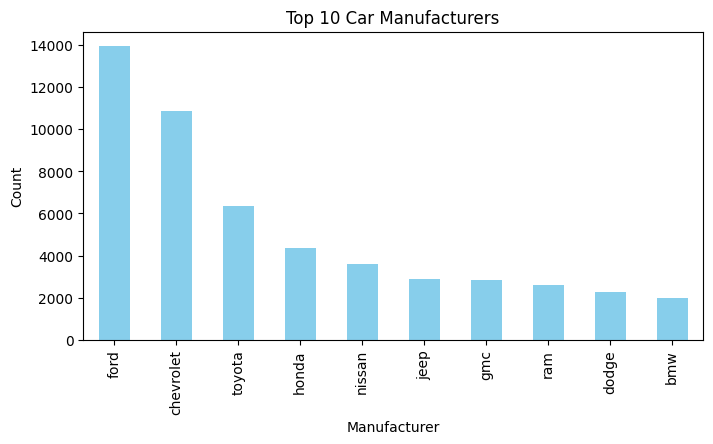

In [ ]:

brand_counts = df['manufacturer'].value_counts().head(10)
plt.figure(figsize=(8,4))
brand_counts.plot(kind='bar', color='skyblue')
plt.title('Top 10 Car Manufacturers')
plt.xlabel('Manufacturer')
plt.ylabel('Count')
plt.show()



### Histogram Example

Histograms are used to visualize the distribution of numerical data.


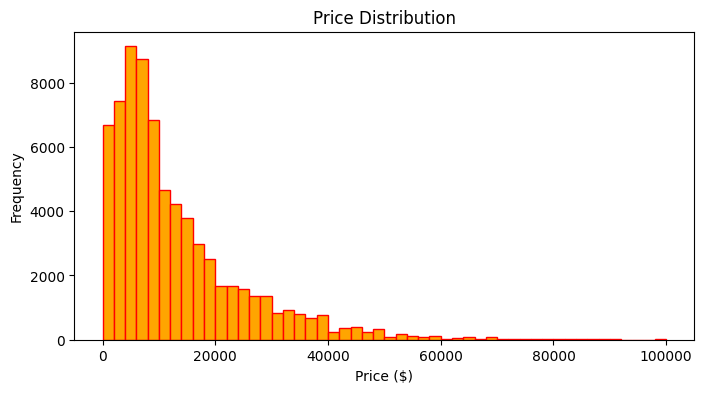

In [ ]:

plt.figure(figsize=(8,4))
plt.hist(df['price'], bins=50, color='orange', edgecolor='red',range=(0,100000))
plt.title('Price Distribution')
plt.xlabel('Price ($)')
plt.ylabel('Frequency')
plt.show()


In [ ]:
toyota_df = df[df["manufacturer"]=="toyota"]
honda_df = df[df["manufacturer"]=="honda"]
ford_df = df[df["manufacturer"]=="ford"]


## 3. Customizing Plots

Matplotlib allows you to customize almost every element of a plot: colors, titles, labels, legends, grids, etc.


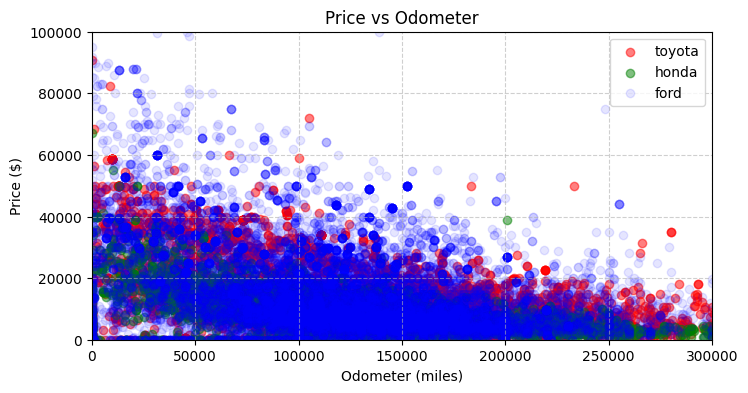

In [ ]:

plt.figure(figsize=(8,4))
plt.scatter(toyota_df['odometer'], toyota_df['price'], alpha=0.5, color='red', label='toyota')
plt.scatter(honda_df['odometer'], honda_df['price'], alpha=0.5, color='green', label='honda')
plt.scatter(ford_df['odometer'], ford_df['price'], alpha=0.1, color='blue', label='ford')
plt.title('Price vs Odometer')
plt.xlabel('Odometer (miles)')
plt.ylabel('Price ($)')
plt.xlim(0, 300000)
plt.ylim(0, 100000)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()



## 4. Multiple Plots (Subplots)
You can display multiple plots in one figure using `plt.subplot()` or `plt.subplots()`.


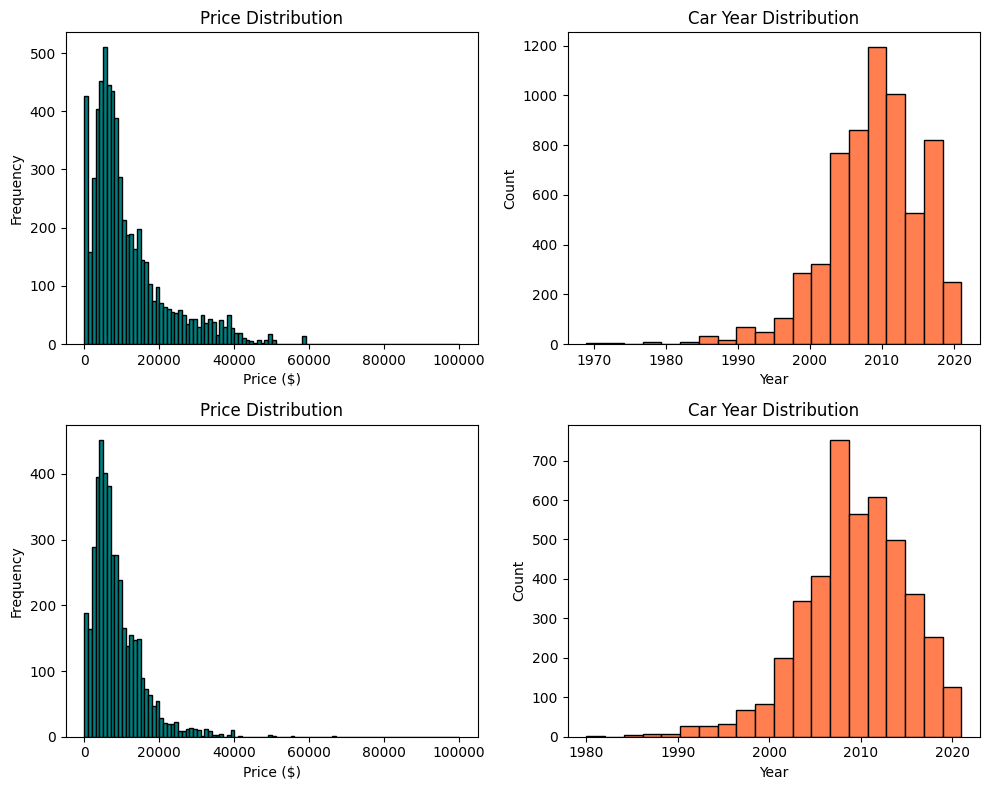

In [ ]:

fig, axes = plt.subplots(2, 2, figsize=(10,8))

# Price distribution
axes[0][0].hist(toyota_df['price'], bins=100, color='teal', edgecolor='black',range=(0,100000))
axes[0][0].set_title('Price Distribution')
axes[0][0].set_xlabel('Price ($)')
axes[0][0].set_ylabel('Frequency')
# Year distribution
axes[0][1].hist(toyota_df['year'], bins=20, color='coral', edgecolor='black')
axes[0][1].set_title('Car Year Distribution')
axes[0][1].set_xlabel('Year')
axes[0][1].set_ylabel('Count')

# Price distribution
axes[1][0].hist(honda_df['price'], bins=100, color='teal', edgecolor='black',range=(0,100000))
axes[1][0].set_title('Price Distribution')
axes[1][0].set_xlabel('Price ($)')
axes[1][0].set_ylabel('Frequency')
# Year distribution
axes[1][1].hist(honda_df['year'], bins=20, color='coral', edgecolor='black')
axes[1][1].set_title('Car Year Distribution')
axes[1][1].set_xlabel('Year')
axes[1][1].set_ylabel('Count')

plt.tight_layout()
plt.show()



## 5. Box Plot & Pie Chart Examples


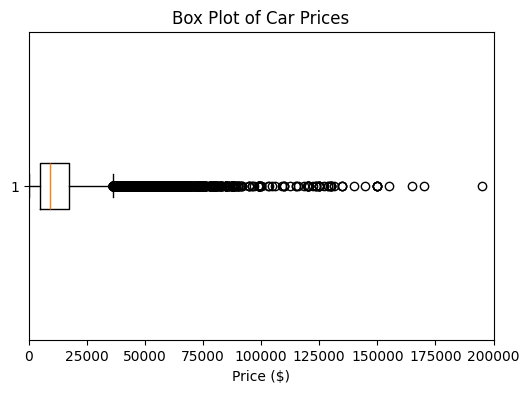

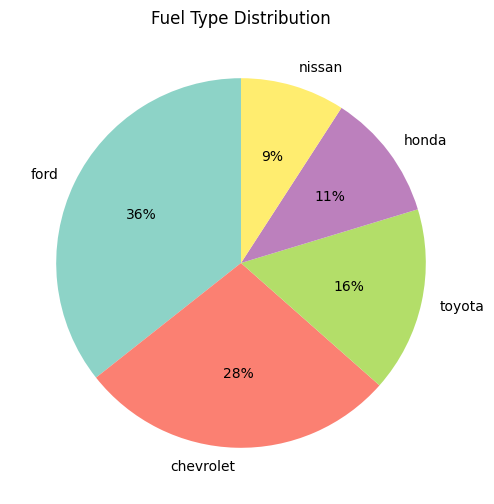

In [ ]:

# Boxplot for Price
plt.figure(figsize=(6,4))
plt.boxplot(df['price'].dropna(), vert=False)
plt.title('Box Plot of Car Prices')
plt.xlabel('Price ($)')
plt.xlim(0, 200000)
plt.show()

# Pie chart for fuel type
plt.figure(figsize=(6,6))
df['manufacturer'].value_counts().head(5).plot(kind='pie', autopct='%1.0f%%', startangle=90, colormap='Set3')
plt.title('Fuel Type Distribution')
plt.ylabel('')
plt.show()



## 6. Summary

In this notebook, you learned how to:
- Create different types of plots in Matplotlib
- Customize plot aesthetics (titles, labels, legends, colors)
- Combine multiple plots in one figure
- Visualize distributions, relationships, and categorical data

**Practice Ideas:**
- Try changing colors, styles, or layouts.
- Explore `plt.subplots()` with 2×2 grids.
- Experiment with `plt.style.use('ggplot')` or `seaborn` styles.
